<a href="https://colab.research.google.com/github/SwayashmCS23157/MLkiRepository/blob/main/SwayashMlprac7Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Lab 7 : To apply support vector machine for classification and analyze the impact od different kernels on model accuracy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
path="/content/drive/MyDrive/ML/pulsar_stars.csv"
df=pd.read_csv(path)
df.head(5)

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17898 entries, 0 to 17897
Data columns (total 9 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0    Mean of the integrated profile                17898 non-null  float64
 1    Standard deviation of the integrated profile  17898 non-null  float64
 2    Excess kurtosis of the integrated profile     17898 non-null  float64
 3    Skewness of the integrated profile            17898 non-null  float64
 4    Mean of the DM-SNR curve                      17898 non-null  float64
 5    Standard deviation of the DM-SNR curve        17898 non-null  float64
 6    Excess kurtosis of the DM-SNR curve           17898 non-null  float64
 7    Skewness of the DM-SNR curve                  17898 non-null  float64
 8   target_class                                   17898 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.2 MB


In [ ]:
df.shape
df.describe()

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


In [ ]:
df.columns
df.isnull().any().any()
df.isnull().sum()

,0
Mean of the integrated profile,0
Standard deviation of the integrated profile,0
Excess kurtosis of the integrated profile,0
Skewness of the integrated profile,0
Mean of the DM-SNR curve,0
Standard deviation of the DM-SNR curve,0
Excess kurtosis of the DM-SNR curve,0
Skewness of the DM-SNR curve,0
target_class,0


In [ ]:
df[df.isnull().any(axis=1)]

,Mean of the integrated profile,Standard deviation of the integrated profile,Excess kurtosis of the integrated profile,Skewness of the integrated profile,Mean of the DM-SNR curve,Standard deviation of the DM-SNR curve,Excess kurtosis of the DM-SNR curve,Skewness of the DM-SNR curve,target_class


In [ ]:
df.drop('number', axis=1, inplace=True, errors='ignore')
df.columns

Index([' Mean of the integrated profile',
       ' Standard deviation of the integrated profile',
       ' Excess kurtosis of the integrated profile',
       ' Skewness of the integrated profile', ' Mean of the DM-SNR curve',
       ' Standard deviation of the DM-SNR curve',
       ' Excess kurtosis of the DM-SNR curve', ' Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [ ]:
df.columns=df.columns.str.strip()
df.columns

Index(['Mean of the integrated profile',
       'Standard deviation of the integrated profile',
       'Excess kurtosis of the integrated profile',
       'Skewness of the integrated profile', 'Mean of the DM-SNR curve',
       'Standard deviation of the DM-SNR curve',
       'Excess kurtosis of the DM-SNR curve', 'Skewness of the DM-SNR curve',
       'target_class'],
      dtype='object')

In [ ]:
df.columns = ['IP mean', 'IP std','IP kurtosis','IP skewness','mean DM_SNR','std_DM_SNR','DM_SNR_kurtosis','DM_SNR_skewness','target']
print(df.columns)

Index(['IP mean', 'IP std', 'IP kurtosis', 'IP skewness', 'mean DM_SNR',
       'std_DM_SNR', 'DM_SNR_kurtosis', 'DM_SNR_skewness', 'target'],
      dtype='object')


In [ ]:
df.shape

(17898, 9)

In [ ]:
df['target'].value_counts()

,count
target,
0,16259
1,1639


In [ ]:
x=df.iloc[:,:-1]
print(x)

          IP mean     IP std  IP kurtosis  IP skewness  mean DM_SNR  \
0      140.562500  55.683782    -0.234571    -0.699648     3.199833   
1      102.507812  58.882430     0.465318    -0.515088     1.677258   
2      103.015625  39.341649     0.323328     1.051164     3.121237   
3      136.750000  57.178449    -0.068415    -0.636238     3.642977   
4       88.726562  40.672225     0.600866     1.123492     1.178930   
...           ...        ...          ...          ...          ...   
17893  136.429688  59.847421    -0.187846    -0.738123     1.296823   
17894  122.554688  49.485605     0.127978     0.323061    16.409699   
17895  119.335938  59.935939     0.159363    -0.743025    21.430602   
17896  114.507812  53.902400     0.201161    -0.024789     1.946488   
17897   57.062500  85.797340     1.406391     0.089520   188.306020   

       std_DM_SNR  DM_SNR_kurtosis  DM_SNR_skewness  
0       19.110426         7.975532        74.242225  
1       14.860146        10.576487     

In [ ]:
y=df.iloc[:,-1]
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
17893    0
17894    0
17895    0
17896    0
17897    0
Name: target, Length: 17898, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,test_size=0.3,random_state=42)
x_train.shape, x_test.shape

((12528, 8), (5370, 8))

In [ ]:
x_train

,IP mean,IP std,IP kurtosis,IP skewness,mean DM_SNR,std_DM_SNR,DM_SNR_kurtosis,DM_SNR_skewness
12223,121.156250,48.372971,0.375485,-0.013165,3.168896,18.399367,7.449874,65.159298
1919,76.968750,36.175557,0.712898,3.388719,2.399666,17.570997,9.414652,102.722975
2753,130.585938,53.229534,0.133408,-0.297242,2.743311,22.362553,8.508364,74.031324
17220,156.398438,48.865942,-0.215989,-0.171294,17.471572,54.469915,2.958066,7.197842
12110,84.804688,36.117659,0.825013,3.274125,2.790134,20.618009,8.405008,76.291128
...,...,...,...,...,...,...,...,...
11284,124.312500,53.179053,-0.012418,-0.556021,7.186455,29.308266,4.531382,21.725143
11964,115.617188,46.784600,0.218177,0.226757,6.140468,30.271961,5.732201,34.357282
5390,116.031250,43.213846,0.663456,0.433088,0.785117,11.628149,17.055215,312.204325
860,135.664062,49.933749,-0.089940,-0.226726,3.859532,21.501505,7.398395,62.334018


In [ ]:
x_test

,IP mean,IP std,IP kurtosis,IP skewness,mean DM_SNR,std_DM_SNR,DM_SNR_kurtosis,DM_SNR_skewness
15985,116.906250,48.920605,0.186046,-0.129815,3.037625,17.737102,8.122621,78.813405
8188,75.585938,34.386254,2.025498,8.652913,3.765050,21.897049,7.048189,55.878791
8157,103.273438,46.996628,0.504295,0.821088,2.244983,15.622566,9.330498,105.134941
2589,101.078125,48.587487,1.011427,1.151870,81.887960,81.464136,0.485105,-1.117904
11909,113.226562,48.608804,0.291538,0.292120,6.291806,26.585056,4.540138,21.708268
...,...,...,...,...,...,...,...,...
12653,116.531250,51.140269,-0.001220,-0.184189,4.510870,26.599514,6.634989,45.362390
6454,114.976562,53.783052,0.377599,-0.155708,2.772575,20.838488,8.440796,77.355028
530,136.171875,48.924385,-0.019473,0.063227,2.810201,18.695230,7.848577,69.388978
1540,106.500000,49.066122,0.245742,0.140377,2.331104,15.417568,9.008041,100.367616


In [ ]:
y_train

,target
12223,0
1919,0
2753,0
17220,0
12110,0
...,...
11284,0
11964,0
5390,0
860,0


In [ ]:
y_test

,target
15985,0
8188,1
8157,0
2589,1
11909,0
...,...
12653,0
6454,0
530,0
1540,0


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc=sc.transform(x_test)

In [ ]:
x_train

array([[ 0.39398903,  0.27225212, -0.09759786, ..., -0.40338108,
        -0.19481754, -0.37780071],
       [-1.32725743, -1.52127273,  0.21878252, ..., -0.44578706,
         0.23837256, -0.02857034],
       [ 0.76130595,  0.98636783, -0.3245843 , ..., -0.2004973 ,
         0.038556  , -0.29531727],
       ...,
       [ 0.19435365, -0.48635278,  0.17242235, ..., -0.75001383,
         1.92294752,  1.91898259],
       [ 0.95911539,  0.50175114, -0.53401036, ..., -0.24457614,
        -0.20616758, -0.4040674 ],
       [ 0.37725131,  0.58093396, -0.12507761, ..., -0.74159513,
         2.05677923,  2.08022728]])

In [ ]:
x_test

array([[ 0.22843774,  0.35277695, -0.27522748, ..., -0.43728381,
        -0.04649179, -0.25085816],
       [-1.38112247, -1.78437423,  1.44956147, ..., -0.22432742,
        -0.28338031, -0.46408179],
       [-0.30260453,  0.0698727 ,  0.02318325, ..., -0.54553131,
         0.21981851, -0.00614623],
       ...,
       [ 0.97889633,  0.3533328 , -0.46793554, ..., -0.3882352 ,
        -0.10691249, -0.33847727],
       [-0.17691945,  0.37417406, -0.21925266, ..., -0.55602557,
         0.1487237 , -0.05046816],
       [-0.01410706, -1.21585526, -0.01840983, ..., -0.20872688,
        -0.52776711, -0.61373985]])

In [ ]:
y_train

,target
12223,0
1919,0
2753,0
17220,0
12110,0
...,...
11284,0
11964,0
5390,0
860,0


In [ ]:
y_test

,target
15985,0
8188,1
8157,0
2589,1
11909,0
...,...
12653,0
6454,0
530,0
1540,0


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC()
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.9789571694599628


Confusion Matrix:
 [[4863   21]
 [  92  394]]


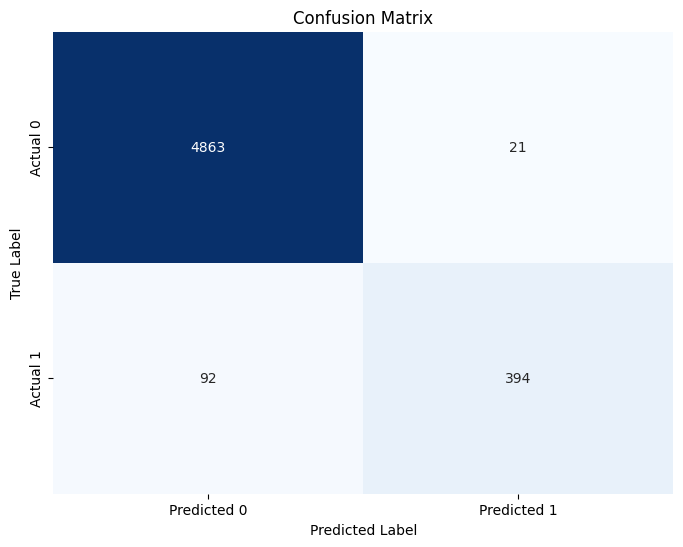

In [ ]:
from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4884
           1       0.95      0.81      0.87       486

    accuracy                           0.98      5370
   macro avg       0.97      0.90      0.93      5370
weighted avg       0.98      0.98      0.98      5370



In [ ]:
svc=SVC(C=100.0)
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.9802607076350093


In [ ]:
svc=SVC(C=1000.0)
svc.fit(x_train,y_train)
y_pred=svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.9797020484171323


In [ ]:
linear_svc=SVC(kernel='linear',C=1.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.9787709497206704


In [ ]:
linear_svc=SVC(kernel='linear',C=100.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.978584729981378


In [ ]:
linear_svc=SVC(kernel='linear',C=1000.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.978584729981378


In [ ]:
linear_svc=SVC(kernel='poly',C=1.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.9769087523277468


In [ ]:
linear_svc=SVC(kernel='poly',C=100.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.9793296089385475


In [ ]:
linear_svc=SVC(kernel='poly',C=1000.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.9793296089385475


In [ ]:
linear_svc=SVC(kernel='sigmoid',C=1.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.8772811918063315


In [ ]:
linear_svc=SVC(kernel='sigmoid',C=100.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.8772811918063315


In [ ]:
linear_svc=SVC(kernel='sigmoid',C=1000.0)
linear_svc.fit(x_train,y_train)
y_pred=linear_svc.predict(x_test)
print("Model accuracy score with default hyperparameters: ")
print(accuracy_score(y_test,y_pred))

Model accuracy score with default hyperparameters: 
0.8772811918063315
